# Projeto Final - Ciencia de Dados EBAC
## Previsao de Resultado de Partidas de League of Legends (LoL)

**Problema:** prever se o Blue Team vencera (`blueWins = 1`) usando o estado da partida aos 10 minutos.

O notebook documenta o fluxo completo: entendimento, auditoria, EDA, testes estatisticos, preparacao, comparacao de modelos, tuning, avaliacao final e interpretacao.

## 1. Configuracao e carregamento

In [1]:
from pathlib import Path
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy.stats import chi2_contingency, mannwhitneyu
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, log_loss, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay
RANDOM_STATE=42
paths=[Path("Base_M43_Pratique_LOL_RANKED_WIN.csv"),Path("../data/Base_M43_Pratique_LOL_RANKED_WIN.csv"),Path("/mnt/data/Base_M43_Pratique_LOL_RANKED_WIN.csv")]
csv_path=next(p for p in paths if p.exists())
df=pd.read_csv(csv_path)
print(f"Base: {df.shape[0]:,} partidas x {df.shape[1]} colunas")
df.head()

Base: 9,879 partidas x 40 colunas


,gameId,blueWins,blueWardsPlaced,blueWardsDestroyed,blueFirstBlood,blueKills,blueDeaths,blueAssists,blueEliteMonsters,blueDragons,blueHeralds,blueTowersDestroyed,blueTotalGold,blueAvgLevel,blueTotalExperience,blueTotalMinionsKilled,blueTotalJungleMinionsKilled,blueGoldDiff,blueExperienceDiff,blueCSPerMin,blueGoldPerMin,redWardsPlaced,redWardsDestroyed,redFirstBlood,redKills,redDeaths,redAssists,redEliteMonsters,redDragons,redHeralds,redTowersDestroyed,redTotalGold,redAvgLevel,redTotalExperience,redTotalMinionsKilled,redTotalJungleMinionsKilled,redGoldDiff,redExperienceDiff,redCSPerMin,redGoldPerMin
0,4519157822,0,28,2,1,9,6,11,0,0,0,0,17210,6.6,17039,195,36,643,-8,19.5,1721.0,15,6,0,6,9,8,0,0,0,0,16567,6.8,17047,197,55,-643,8,19.7,1656.7
1,4523371949,0,12,1,0,5,5,5,0,0,0,0,14712,6.6,16265,174,43,-2908,-1173,17.4,1471.2,12,1,1,5,5,2,2,1,1,1,17620,6.8,17438,240,52,2908,1173,24.0,1762.0
2,4521474530,0,15,0,0,7,11,4,1,1,0,0,16113,6.4,16221,186,46,-1172,-1033,18.6,1611.3,15,3,1,11,7,14,0,0,0,0,17285,6.8,17254,203,28,1172,1033,20.3,1728.5
3,4524384067,0,43,1,0,4,5,5,1,0,1,0,15157,7.0,17954,201,55,-1321,-7,20.1,1515.7,15,2,1,5,4,10,0,0,0,0,16478,7.0,17961,235,47,1321,7,23.5,1647.8
4,4436033771,0,75,4,0,6,6,6,0,0,0,0,16400,7.0,18543,210,57,-1004,230,21.0,1640.0,17,2,1,6,6,7,1,1,0,0,17404,7.0,18313,225,67,1004,-230,22.5,1740.4


## 2. Auditoria da base
Verificamos tipos, ausencias, duplicatas, unicidade do identificador e equilibrio do alvo. Nao faremos imputacao ou reamostragem sem necessidade.

In [2]:
audit=pd.Series({"linhas":len(df),"colunas":df.shape[1],"nulos":int(df.isna().sum().sum()),"duplicadas":int(df.duplicated().sum()),"gameId_duplicados":int(df.gameId.duplicated().sum())})
print(audit)
print("\nDistribuicao target (%):")
print((df.blueWins.value_counts(normalize=True).sort_index()*100).round(2))

linhas               9879
colunas                40
nulos                   0
duplicadas              0
gameId_duplicados       0
dtype: int64

Distribuicao target (%):
blueWins
0    50.1
1    49.9
Name: proportion, dtype: float64


## 3. Redundancias demonstraveis
A base contem espelhos entre equipes e transformacoes deterministicas. Documentamos essas relacoes antes de remove-las da modelagem.

In [3]:
checks={
"blueGoldDiff == -redGoldDiff":np.all(df.blueGoldDiff==-df.redGoldDiff),
"blueExperienceDiff == -redExperienceDiff":np.all(df.blueExperienceDiff==-df.redExperienceDiff),
"blueKills == redDeaths":np.all(df.blueKills==df.redDeaths),
"blueDeaths == redKills":np.all(df.blueDeaths==df.redKills),
"blueCSPerMin == blueTotalMinionsKilled/10":np.allclose(df.blueCSPerMin,df.blueTotalMinionsKilled/10),
"redCSPerMin == redTotalMinionsKilled/10":np.allclose(df.redCSPerMin,df.redTotalMinionsKilled/10),
"blueGoldPerMin == blueTotalGold/10":np.allclose(df.blueGoldPerMin,df.blueTotalGold/10),
"redGoldPerMin == redTotalGold/10":np.allclose(df.redGoldPerMin,df.redTotalGold/10)}
pd.Series(checks)

blueGoldDiff == -redGoldDiff                 True
blueExperienceDiff == -redExperienceDiff     True
blueKills == redDeaths                       True
blueDeaths == redKills                       True
blueCSPerMin == blueTotalMinionsKilled/10    True
redCSPerMin == redTotalMinionsKilled/10      True
blueGoldPerMin == blueTotalGold/10           True
redGoldPerMin == redTotalGold/10             True
dtype: bool

## 4. Analise exploratoria
Investigamos correlacao com o alvo e eventos estrategicos. Correlacao indica associacao, nao causalidade.

redGoldDiff           -0.511
blueGoldDiff           0.511
blueExperienceDiff     0.490
redExperienceDiff     -0.490
blueTotalGold          0.417
blueGoldPerMin         0.417
redTotalGold          -0.411
redGoldPerMin         -0.411
blueTotalExperience    0.396
redTotalExperience    -0.388
blueAvgLevel           0.358
redAvgLevel           -0.352
Name: blueWins, dtype: float64


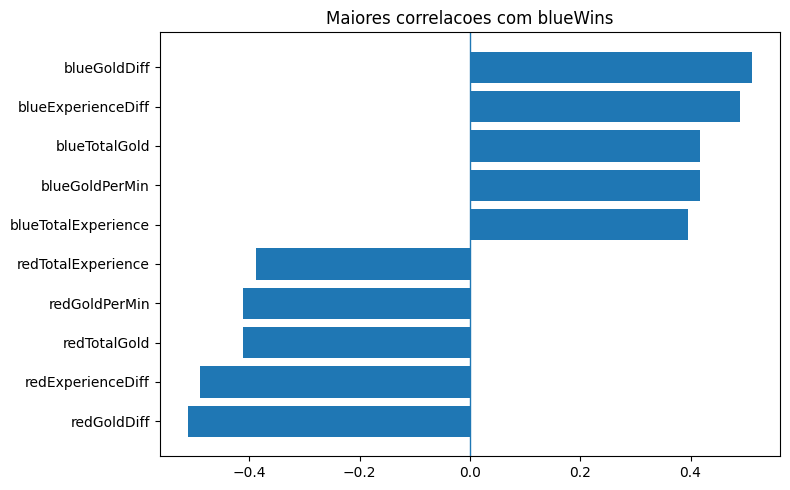

In [4]:
corr=df.drop(columns="gameId").corr(numeric_only=True)["blueWins"].drop("blueWins").sort_values(key=abs,ascending=False)
print(corr.head(12).round(3))
fig,ax=plt.subplots(figsize=(8,5)); top=corr.head(10).sort_values(); ax.barh(top.index,top.values); ax.axvline(0,lw=1); ax.set_title("Maiores correlacoes com blueWins"); plt.tight_layout(); plt.show()

In [5]:
for f in ["blueFirstBlood","blueDragons","blueHeralds","blueTowersDestroyed"]:
    print("\n",f); print((df.groupby(f).blueWins.agg(["count","mean"]).assign(mean=lambda x:x["mean"]*100)).round(2))


 blueFirstBlood
                count   mean
blueFirstBlood              
0                4892  39.72
1                4987  59.90

 blueDragons
             count   mean
blueDragons              
0             6303  41.85
1             3576  64.09

 blueHeralds
             count   mean
blueHeralds              
0             8022  47.68
1             1857  59.50

 blueTowersDestroyed
                     count    mean
blueTowersDestroyed               
0                     9415   48.65
1                      429   73.66
2                       27   96.30
3                        7  100.00
4                        1  100.00


### Vantagem de ouro e probabilidade observada de vitoria

gold_band
Grande desvantagem    13.60
Desvantagem           32.39
Equilibrio            49.16
Vantagem              67.38
Grande vantagem       87.04
Name: blueWins, dtype: float64


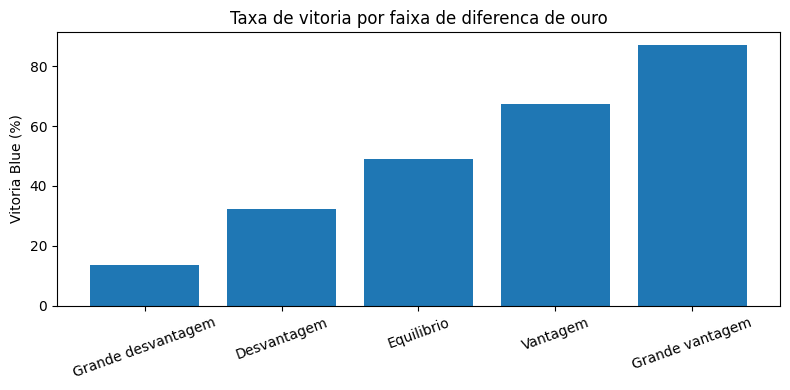

In [6]:
labels=["Grande desvantagem","Desvantagem","Equilibrio","Vantagem","Grande vantagem"]
df2=df.copy(); df2["gold_band"]=pd.qcut(df2.blueGoldDiff,5,labels=labels)
gold=(df2.groupby("gold_band",observed=True).blueWins.mean()*100)
print(gold.round(2))
fig,ax=plt.subplots(figsize=(8,4)); ax.bar(gold.index.astype(str),gold.values); ax.set_ylabel("Vitoria Blue (%)"); ax.set_title("Taxa de vitoria por faixa de diferenca de ouro"); ax.tick_params(axis="x",rotation=20); plt.tight_layout(); plt.show()

## 5. Testes estatisticos
Para eventos binarios usamos qui-quadrado de independencia. Para `blueGoldDiff`, comparamos vencedores e perdedores pelo teste de Mann-Whitney. Nivel de significancia: 5%.

In [7]:
rows=[]
for f in ["blueFirstBlood","blueDragons","blueHeralds"]:
    tab=pd.crosstab(df[f],df.blueWins); chi2,p,_,_=chi2_contingency(tab); rows.append([f,"Qui-quadrado",p])
u,p=mannwhitneyu(df.loc[df.blueWins==1,"blueGoldDiff"],df.loc[df.blueWins==0,"blueGoldDiff"],alternative="two-sided"); rows.append(["blueGoldDiff","Mann-Whitney",p])
tests=pd.DataFrame(rows,columns=["variavel","teste","p_value"]); tests["significativo_5pct"]=tests.p_value<.05; tests

,variavel,teste,p_value,significativo_5pct
0,blueFirstBlood,Qui-quadrado,2.763610e-89,True
1,blueDragons,Qui-quadrado,5.481573e-100,True
2,blueHeralds,Qui-quadrado,5.352956e-20,True
3,blueGoldDiff,Mann-Whitney,0.000000e+00,True


## 6. Preparacao dos dados
`gameId` e removido por ser identificador. Removemos apenas redundancias exatas demonstradas. O split e estratificado (80/20). **O conjunto de teste fica fechado durante comparacao e tuning.**

In [8]:
y=df.blueWins.copy(); X_raw=df.drop(columns=["blueWins","gameId"])
drop_redundant=["redGoldDiff","redExperienceDiff","redKills","redDeaths","blueGoldPerMin","redGoldPerMin","blueCSPerMin","redCSPerMin"]
X=X_raw.drop(columns=drop_redundant).copy()
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=.20,stratify=y,random_state=RANDOM_STATE)
print("Features:",X.shape[1]); print("Treino:",X_train.shape,"Teste reservado:",X_test.shape)

Features: 30
Treino: (7903, 30) Teste reservado: (1976, 30)


## 7. Baseline e comparacao de modelos
A comparacao usa somente treino com Stratified 5-Fold CV. Avaliamos Accuracy, Precision, Recall, F1, ROC-AUC e Log Loss.

In [9]:
cv=StratifiedKFold(n_splits=5,shuffle=True,random_state=RANDOM_STATE)
models={
"Dummy":DummyClassifier(strategy="most_frequent"),
"Regressao Logistica":Pipeline([("scaler",StandardScaler()),("model",LogisticRegression(max_iter=2000,random_state=RANDOM_STATE))]),
"Decision Tree":DecisionTreeClassifier(random_state=RANDOM_STATE),
"Random Forest":RandomForestClassifier(n_estimators=120,random_state=RANDOM_STATE,n_jobs=1),
"SVM":Pipeline([("scaler",StandardScaler()),("model",LinearSVC(random_state=RANDOM_STATE))])}
scoring={"accuracy":"accuracy","precision":"precision","recall":"recall","f1":"f1","roc_auc":"roc_auc"}
rows=[]
for name,m in models.items():
    r=cross_validate(m,X_train,y_train,cv=cv,scoring=scoring,n_jobs=1)
    rows.append({"Modelo":name,"Accuracy":r["test_accuracy"].mean(),"Precision":r["test_precision"].mean(),"Recall":r["test_recall"].mean(),"F1":r["test_f1"].mean(),"ROC-AUC":r["test_roc_auc"].mean()})
comparison=pd.DataFrame(rows).sort_values("ROC-AUC",ascending=False); comparison.round(4)

,Modelo,Accuracy,Precision,Recall,F1,ROC-AUC
1,Regressao Logistica,0.7348,0.7359,0.7310,0.7332,0.8107
4,SVM,0.7339,0.7345,0.7312,0.7326,0.8107
3,Random Forest,0.7229,0.7272,0.7122,0.7193,0.7969
2,Decision Tree,0.6351,0.6354,0.6298,0.6324,0.6351
0,Dummy,0.5009,0.0000,0.0000,0.0000,0.5000


## 8. Tuning da Regressao Logistica
Como a Regressao Logistica lidera a validacao cruzada e oferece boa interpretabilidade, ajustamos a intensidade de regularizacao `C` via GridSearchCV, ainda sem consultar o teste.

In [10]:
pipe=Pipeline([("scaler",StandardScaler()),("model",LogisticRegression(max_iter=2000,random_state=RANDOM_STATE))])
grid=GridSearchCV(pipe,{"model__C":[.01,.03,.1,.3,1,3,10]},scoring="roc_auc",cv=cv,n_jobs=-1,return_train_score=False)
grid.fit(X_train,y_train)
tuning=pd.DataFrame(grid.cv_results_)[["param_model__C","mean_test_score","std_test_score"]].sort_values("mean_test_score",ascending=False)
print("Melhor C:",grid.best_params_["model__C"],"| ROC-AUC CV:",round(grid.best_score_,5)); tuning.round(5)

Melhor C: 0.03 | ROC-AUC CV: 0.81088


,param_model__C,mean_test_score,std_test_score
1,0.03,0.81088,0.00851
2,0.10,0.81081,0.00818
3,0.30,0.81075,0.00800
4,1.00,0.81074,0.00794
5,3.00,0.81073,0.00791
6,10.00,0.81072,0.00791
0,0.01,0.81068,0.00887


## 9. Avaliacao final - conjunto de teste nunca usado na selecao
Depois de congelar o modelo, abrimos o teste uma unica vez. Estes sao os numeros oficiais do projeto.

Accuracy     0.7166
Precision    0.7117
Recall       0.7262
F1           0.7189
ROC-AUC      0.8060
Log Loss     0.5313
dtype: float64
[[700 290]
 [270 716]]


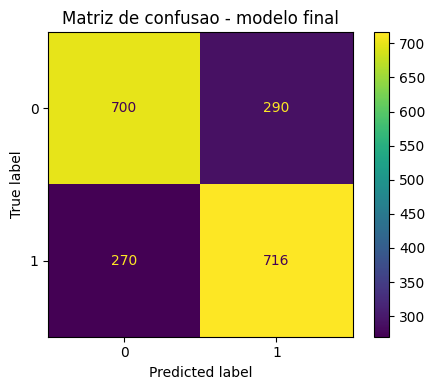

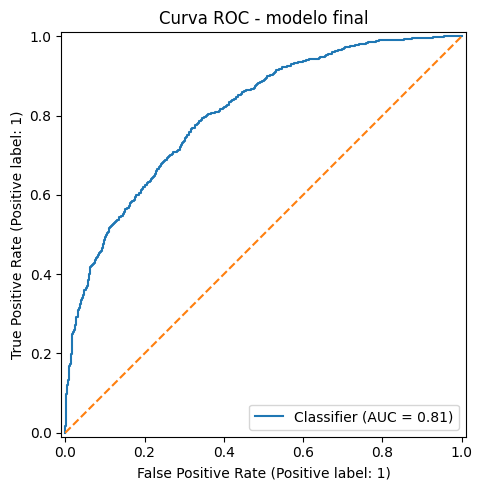

In [11]:
final_model=grid.best_estimator_
pred=final_model.predict(X_test); proba=final_model.predict_proba(X_test)[:,1]
metrics=pd.Series({"Accuracy":accuracy_score(y_test,pred),"Precision":precision_score(y_test,pred),"Recall":recall_score(y_test,pred),"F1":f1_score(y_test,pred),"ROC-AUC":roc_auc_score(y_test,proba),"Log Loss":log_loss(y_test,proba)})
print(metrics.round(4))
print(confusion_matrix(y_test,pred))
fig,ax=plt.subplots(figsize=(5,4)); ConfusionMatrixDisplay.from_predictions(y_test,pred,ax=ax); ax.set_title("Matriz de confusao - modelo final"); plt.tight_layout(); plt.show()
fig,ax=plt.subplots(figsize=(6,5)); RocCurveDisplay.from_predictions(y_test,proba,ax=ax); ax.plot([0,1],[0,1],"--"); ax.set_title("Curva ROC - modelo final"); plt.tight_layout(); plt.show()

## 10. Interpretacao do modelo final
Como as features foram padronizadas, os coeficientes da regressao podem ser comparados em magnitude. Coeficiente positivo favorece a classe `blueWins=1`; negativo favorece derrota Blue. Isso e interpretacao preditiva, nao causal.

redTotalGold             -0.356
redTotalExperience       -0.223
redDragons               -0.100
redEliteMonsters         -0.068
blueTotalMinionsKilled   -0.053
blueWardsPlaced          -0.038
blueHeralds              -0.035
blueAssists              -0.023
blueEliteMonsters         0.061
blueAvgLevel              0.070
redTotalMinionsKilled     0.080
blueTotalExperience       0.087
blueDragons               0.108
blueExperienceDiff        0.194
blueTotalGold             0.377
blueGoldDiff              0.454
Name: coeficiente, dtype: float64


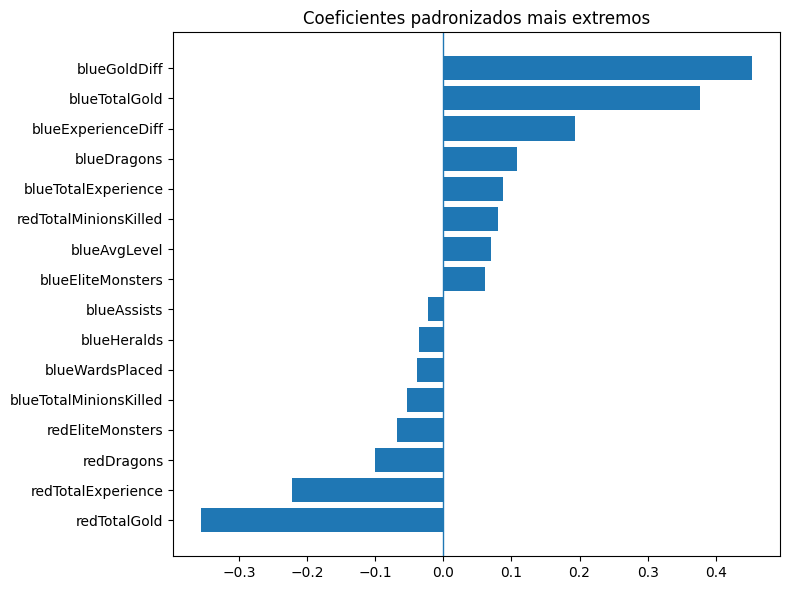

In [12]:
coef=pd.Series(final_model.named_steps["model"].coef_[0],index=X.columns,name="coeficiente").sort_values()
extreme=pd.concat([coef.head(8),coef.tail(8)]).sort_values(); print(extreme.round(3))
fig,ax=plt.subplots(figsize=(8,6)); ax.barh(extreme.index,extreme.values); ax.axvline(0,lw=1); ax.set_title("Coeficientes padronizados mais extremos"); plt.tight_layout(); plt.show()

## 11. Confianca das previsoes e erros
A probabilidade prevista permite separar partidas claras de estados equilibrados. Avaliamos isso apenas para interpretar o teste final, sem retreinar o modelo.

In [13]:
confidence=np.maximum(proba,1-proba)
high=confidence>=.80; balanced=(proba>=.40)&(proba<=.60)
summary=pd.DataFrame({"grupo":["Alta confianca (>=80%)","Equilibradas (40%-60% Blue)"],"n":[high.sum(),balanced.sum()],"accuracy":[accuracy_score(y_test[high],pred[high]),accuracy_score(y_test[balanced],pred[balanced])]})
summary.assign(accuracy_pct=lambda x:(x.accuracy*100).round(1))

,grupo,n,accuracy,accuracy_pct
0,Alta confianca (>=80%),725,0.891034,89.1
1,Equilibradas (40%-60% Blue),410,0.536585,53.7


## 12. Conclusoes para o stakeholder

- O estado da partida aos 10 minutos contem sinal preditivo relevante: o modelo final alcanca **aproximadamente 72% de acuracia** e **ROC-AUC em torno de 0,81** em dados nao vistos.
- Vantagens economicas e de experiencia aparecem entre os sinais mais relevantes, coerentes com a EDA.
- Objetivos como dragao tambem acrescentam informacao.
- Partidas com vantagem clara sao mais previsiveis; estados equilibrados permanecem naturalmente incertos.
- O modelo deve ser usado como estimador probabilistico de estado da partida, nao como prova causal de que uma acao isolada produz a vitoria.

### Limitacoes
O dataset representa um recorte especifico de partidas/patch; nao inclui composicao completa de campeoes, habilidade individual, historico do jogador ou evolucao temporal apos o snapshot. Mudancas de meta podem causar drift, portanto um uso em producao exigiria monitoramento e revalidacao.

### Proximos passos
Adicionar composicao de equipes e informacoes temporais, testar calibracao de probabilidades, monitorar drift por patch e avaliar modelos adicionais quando houver ganho justificavel.

## 13. Encerramento
O projeto percorreu o ciclo completo de Ciencia de Dados solicitado: entendimento, qualidade dos dados, EDA, testes estatisticos, preparacao, comparacao de algoritmos, validacao cruzada, tuning, teste final e comunicacao. A principal conclusao e que **o early game ja permite estimar o desfecho com utilidade preditiva, mas a incerteza permanece alta em partidas equilibradas**.